### y = 10x^4 + 5x^3 + 7x^2 + 10x - 20

In [1]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# Polynomial function
def polynomial(x):
    return 10 * x**4 + 5 * x**3 + 7 * x**2 + 10 * x - 20

In [3]:
# Generate data
np.random.seed(4)
x = np.random.uniform(-20, 20, 1000)
y = polynomial(x)

In [4]:
# Normalize to [-1, 1]
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

x_norm = 2 * (x - x_min) / (x_max - x_min) - 1
y_norm = 2 * (y - y_min) / (y_max - y_min) - 1

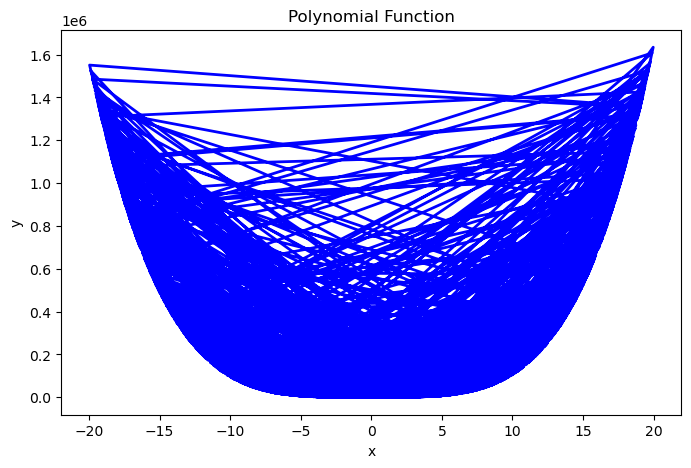

In [5]:
# simple plot this polinomial value
plt.figure(figsize=(8,5))
plt.plot(x, y, color='blue', linewidth=2)
plt.title("Polynomial Function")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

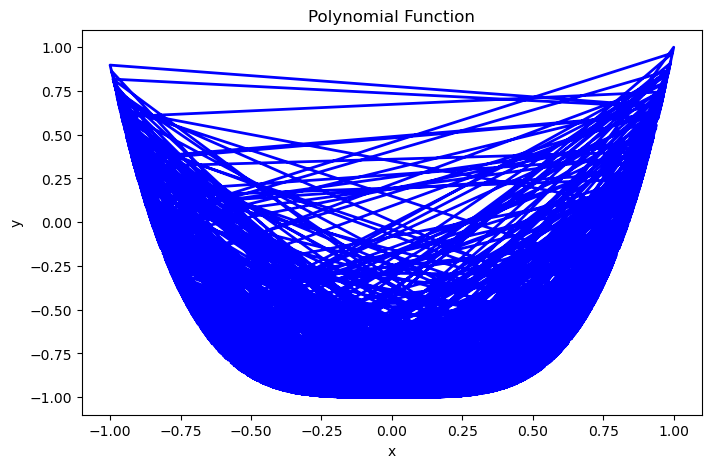

In [6]:
# simple plot this polinomial value
plt.figure(figsize=(8,5))
plt.plot(x_norm, y_norm, color='blue', linewidth=2)
plt.title("Polynomial Function")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
# spit the data into training and testing sets
train_size = int(0.8 * len(x_norm))
x_train, x_test = x_norm[:train_size], x_norm[train_size:]
y_train, y_test = y_norm[:train_size], y_norm[train_size:]

In [8]:
# Reshape the data to be 2D arrays
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [9]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

In [10]:
model = MyModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
model.train()
num_epochs = 50
for epoch in range(num_epochs):
    inputs = torch.from_numpy(x_train).float()
    targets = torch.from_numpy(y_train).float()

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')   

Epoch [1/50], Loss: 1.0155
Epoch [2/50], Loss: 0.9860
Epoch [3/50], Loss: 0.9568
Epoch [4/50], Loss: 0.9283
Epoch [5/50], Loss: 0.9003
Epoch [6/50], Loss: 0.8725
Epoch [7/50], Loss: 0.8455
Epoch [8/50], Loss: 0.8203
Epoch [9/50], Loss: 0.7962
Epoch [10/50], Loss: 0.7740
Epoch [11/50], Loss: 0.7532
Epoch [12/50], Loss: 0.7333
Epoch [13/50], Loss: 0.7139
Epoch [14/50], Loss: 0.6945
Epoch [15/50], Loss: 0.6750
Epoch [16/50], Loss: 0.6553
Epoch [17/50], Loss: 0.6355
Epoch [18/50], Loss: 0.6155
Epoch [19/50], Loss: 0.5954
Epoch [20/50], Loss: 0.5753
Epoch [21/50], Loss: 0.5550
Epoch [22/50], Loss: 0.5346
Epoch [23/50], Loss: 0.5142
Epoch [24/50], Loss: 0.4938
Epoch [25/50], Loss: 0.4735
Epoch [26/50], Loss: 0.4538
Epoch [27/50], Loss: 0.4349
Epoch [28/50], Loss: 0.4165
Epoch [29/50], Loss: 0.3987
Epoch [30/50], Loss: 0.3816
Epoch [31/50], Loss: 0.3654
Epoch [32/50], Loss: 0.3501
Epoch [33/50], Loss: 0.3359
Epoch [34/50], Loss: 0.3232
Epoch [35/50], Loss: 0.3122
Epoch [36/50], Loss: 0.3027
E

In [12]:
# Claculate training and validation loss

train_loss = 0.0
test_loss = 0.0
model.eval()
with torch.no_grad():
    train_inputs = torch.from_numpy(x_train).float()
    train_targets = torch.from_numpy(y_train).float()
    train_outputs = model(train_inputs)
    train_loss = criterion(train_outputs, train_targets)

    test_inputs = torch.from_numpy(x_test).float()
    test_targets = torch.from_numpy(y_test).float()
    test_outputs = model(test_inputs)
    test_loss = criterion(test_outputs, test_targets)
print(f'Training Loss: {train_loss.item():.4f}')
print(f'Validation Loss: {test_loss.item():.4f}')

Training Loss: 0.2416
Validation Loss: 0.2302


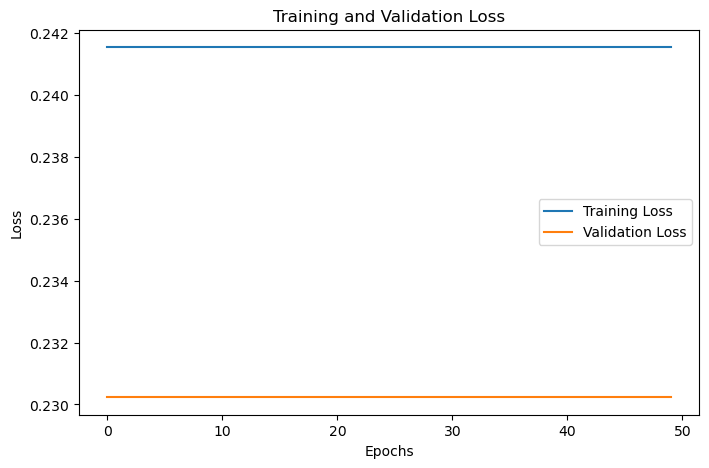

In [13]:
# Plot the training and validation loss
plt.figure(figsize=(8,5))
plt.plot(range(num_epochs), [train_loss.item()]*num_epochs, label='Training Loss')
plt.plot(range(num_epochs), [test_loss.item()]*num_epochs, label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()   

In [ ]:
# calculate the model's predictions on the test set
model.eval()
with torch.no_grad():
    test_inputs = torch.from_numpy(x_test).float()
    test_outputs = model(test_inputs)
    test_predictions = test_outputs.numpy()
    test_loss = criterion(test_outputs, torch.from_numpy(y_test).float()).item()
    

In [16]:
# claculate the f1 and r2 score
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, test_predictions)  
r2 = r2_score(y_test, test_predictions)
r2

0.13752768782043945